# 05 — EDA YouTube Comments

Análisis exploratorio del corpus de comentarios de YouTube sobre IA (2020–2026).
Objetivo: entender los datos antes de la limpieza e identificar qué decisiones
de filtrado son necesarias hacer.

Fuente: `youtube_comments_AI_FULL.csv` — combinación de tres recogidas:
- Early Boom (2020–2023): ~9.500 comentarios
- Post-2024 (2022–2026): ~51.000 comentarios  
- Recogida específica 2024: ~16.000 comentarios

Total: ~74.000 comentarios

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter

# Estilo uniforme para todas las gráficas del TFG
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_colwidth", 80)

df = pd.read_csv("youtube_comments_AI_FULL.csv")

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
df.head(3)

Filas: 89,160
Columnas: 15


,video_id,comment_id,text,likes,date,author,reply_count,video_title,channel,published_at,query_used,video_viewCount,video_commentCount,video_duration_sec,period
0,uTl8ZYImjBQ,UgyXzwVSolSlJAxqjXh4AaABAg,"Most Musicians: Famous, elegant, but drama filled.\nThis one Australian: hol...",0,2023-12-25T01:46:57Z,@cowbell420,0,Artificial Intelligence (Official Video),Tom Cardy,2021-08-05T21:36:52Z,artificial intelligence 2021,2705020,3534,241,2020-2023
1,uTl8ZYImjBQ,UgybRUKiK4o7WRmwvD54AaABAg,Love it!\nHugs from Brazil!\n❤,0,2023-12-24T20:06:55Z,@luandareisoliveira8551,0,Artificial Intelligence (Official Video),Tom Cardy,2021-08-05T21:36:52Z,artificial intelligence 2021,2705020,3534,241,2020-2023
2,uTl8ZYImjBQ,Ugw9ci31VKMV-o7aSPZ4AaABAg,"Tom, can you please release a karaoke version of this track?",0,2023-12-09T07:48:57Z,@SeekerofWeird__,0,Artificial Intelligence (Official Video),Tom Cardy,2021-08-05T21:36:52Z,artificial intelligence 2021,2705020,3534,241,2020-2023


In [2]:
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print("\n=== VALORES NULOS ===")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nTotal filas con al menos un nulo: {df.isnull().any(axis=1).sum():,}")

=== TIPOS DE DATOS ===
video_id              object
comment_id            object
text                  object
likes                  int64
date                  object
author                object
reply_count            int64
video_title           object
channel               object
published_at          object
query_used            object
video_viewCount        int64
video_commentCount     int64
video_duration_sec     int64
period                object
dtype: object

=== VALORES NULOS ===
author    1
dtype: int64

Total filas con al menos un nulo: 1


## 1. Distribución temporal

Verificamos si el volumen de comentarios refleja los hitos reales del debate sobre IA.
El punto de inflexión esperado es noviembre 2022 (lanzamiento de ChatGPT).

C:\Users\mbgaz\AppData\Local\Temp\ipykernel_19860\2550147214.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["comment_month"] = df["date"].dt.to_period("M")


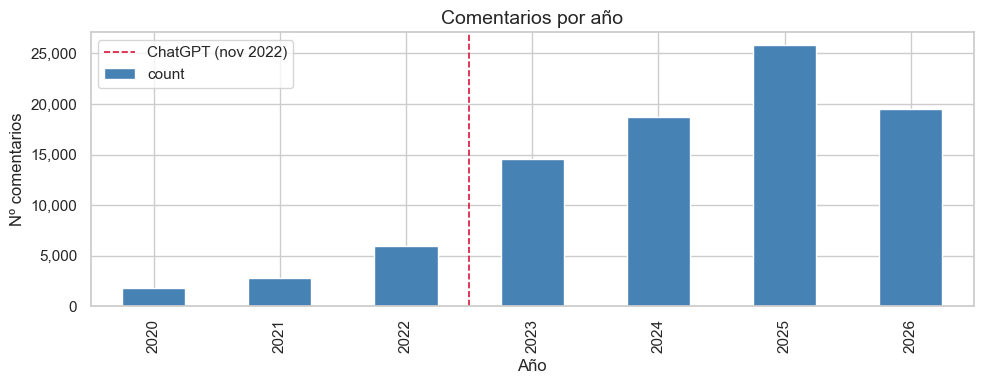

comment_year
2020     1791
2021     2779
2022     5966
2023    14603
2024    18720
2025    25797
2026    19504


In [3]:
df["date"] = pd.to_datetime(df["date"], utc=True, errors="coerce")
df["comment_year"] = df["date"].dt.year
df["comment_month"] = df["date"].dt.to_period("M")

conteo_anual = df["comment_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
conteo_anual.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Comentarios por año", fontsize=14)
ax.set_xlabel("Año")
ax.set_ylabel("Nº comentarios")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Anotamos ChatGPT como referencia visual
if 2022 in conteo_anual.index:
    idx = list(conteo_anual.index).index(2022)
    ax.axvline(x=idx + 0.5, color="crimson", linestyle="--", linewidth=1.2, label="ChatGPT (nov 2022)")
    ax.legend()

plt.tight_layout()
plt.show()

print(conteo_anual.to_string())

## 2. Distribución por query

La clasificación definitiva por topic (education / employment / general) se realizará
en `06_limpieza_youtube.ipynb` por contenido del texto. Aquí se muestra la distribución
por `query_used` como aproximación exploratoria para entender qué aportó cada búsqueda.

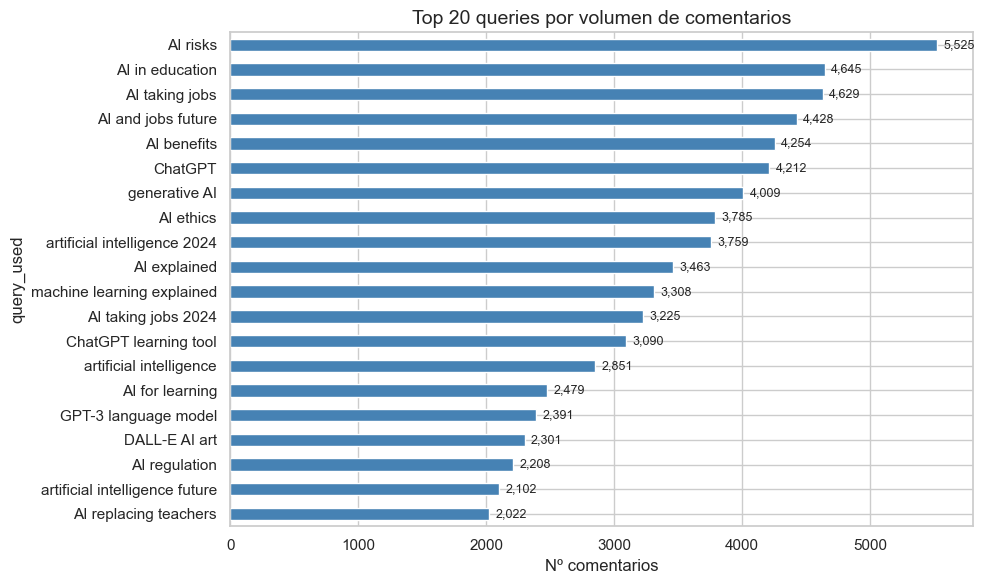

In [5]:
conteo_query = df["query_used"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
conteo_query.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 20 queries por volumen de comentarios", fontsize=14)
ax.set_xlabel("Nº comentarios")
for i, v in enumerate(conteo_query.sort_values()):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 3. Concentración por canal

Datos dominados por pocos canales estaría sesgado hacia la audiencia de esos canales.
Verificamos que la distribución sea suficientemente diversa.

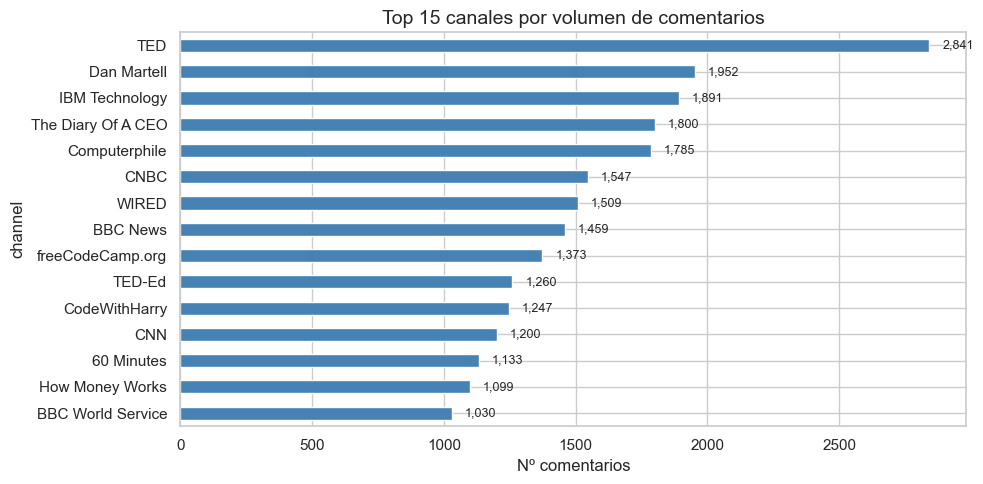

Top 5 canales representan el 11.5% del corpus


In [6]:
top_canales = df["channel"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_canales.sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 canales por volumen de comentarios", fontsize=14)
ax.set_xlabel("Nº comentarios")
for i, v in enumerate(top_canales.sort_values()):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Concentración: ¿cuánto representa el top 5?
top5_pct = top_canales.head(5).sum() / len(df) * 100
print(f"Top 5 canales representan el {top5_pct:.1f}% del corpus")

## 4. Longitud de los comentarios

La longitud determina el umbral de filtrado mínimo en la limpieza. Comentarios muy cortos
("wow", "great video") no aportan señal semántica al modelo de sentimiento.

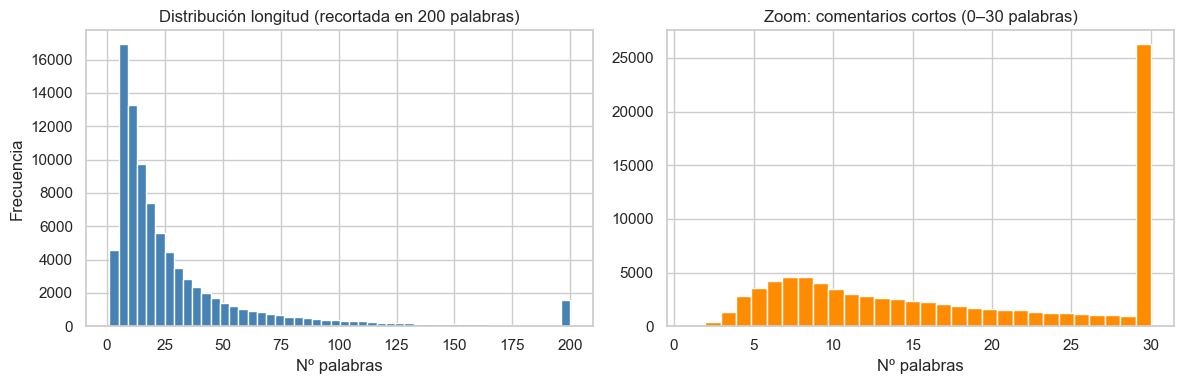

count    89160.0
mean        33.1
std         61.0
min          1.0
25%          9.0
50%         17.0
75%         34.0
max       1881.0
Name: n_palabras, dtype: object

Comentarios con < 5 palabras:  4,596 (5.2%)
Comentarios con < 10 palabras: 25,537 (28.6%)
Comentarios con > 100 palabras: 5,168 (5.8%)


In [7]:
# Número de palabras por comentario
df["n_palabras"] = df["text"].dropna().apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma completo
df["n_palabras"].clip(upper=200).hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribución longitud (recortada en 200 palabras)")
axes[0].set_xlabel("Nº palabras")
axes[0].set_ylabel("Frecuencia")

# Zoom en la parte baja (0-30 palabras) — donde están los comentarios muy cortos
df["n_palabras"].clip(upper=30).hist(bins=30, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("Zoom: comentarios cortos (0–30 palabras)")
axes[1].set_xlabel("Nº palabras")

plt.tight_layout()
plt.show()

print(df["n_palabras"].describe().apply(lambda x: f"{x:.1f}"))
print(f"\nComentarios con < 5 palabras:  {(df['n_palabras'] < 5).sum():,} ({(df['n_palabras'] < 5).mean()*100:.1f}%)")
print(f"Comentarios con < 10 palabras: {(df['n_palabras'] < 10).sum():,} ({(df['n_palabras'] < 10).mean()*100:.1f}%)")
print(f"Comentarios con > 100 palabras: {(df['n_palabras'] > 100).sum():,} ({(df['n_palabras'] > 100).mean()*100:.1f}%)")

## 5. Detección de ruido estructural

Identificamos URLs, menciones, emojis y comentarios del propio canal (spam promocional).

In [8]:
# URLs
tiene_url = df["text"].str.contains(r"http[s]?://|www\.", na=False, regex=True)
# Menciones
tiene_mencion = df["text"].str.contains(r"@\w+", na=False, regex=True)
# Emojis (rango Unicode básico)
tiene_emoji = df["text"].str.contains(
    r"[\U0001F300-\U0001FAFF\u2600-\u26FF\u2700-\u27BF]", na=False, regex=True
)

print("=== RUIDO EN EL TEXTO ===")
print(f"Comentarios con URL:      {tiene_url.sum():,} ({tiene_url.mean()*100:.1f}%)")
print(f"Comentarios con mención:  {tiene_mencion.sum():,} ({tiene_mencion.mean()*100:.1f}%)")
print(f"Comentarios con emoji:    {tiene_emoji.sum():,} ({tiene_emoji.mean()*100:.1f}%)")

# Comentarios del propio canal (posibles pinned/spam)
comentarios_propios = df[df["author"].str.lstrip("@").str.lower() == df["channel"].str.lower()]
print(f"\nComentarios del propio canal: {len(comentarios_propios):,}")
print(comentarios_propios[["channel", "author", "text", "likes"]].head(5).to_string())

=== RUIDO EN EL TEXTO ===
Comentarios con URL:      443 (0.5%)
Comentarios con mención:  353 (0.4%)
Comentarios con emoji:    9,642 (10.8%)

Comentarios del propio canal: 13
              channel           author                                                                                                                                                                                                                                                                                         text  likes
4221   Mrwhosetheboss  @Mrwhosetheboss                                                                                                      Were you surprised at how good the AI was?\nTo see what an AI-Powered Smartphone Gimbal can do: https://youtu.be/oORJNIDy3B0\nAlso stay tuned....got a cool vid for you tomorrow too! 😎   1374
4659              Vox             @Vox  Thanks for watching! The video above is a primer on how we got here, how this technology works, and some of the implications

## 6. Duplicados por contenido

Detectamos textos idénticos con distinto `comment_id`: pueden ser bots, copypastes virales
o el mismo usuario comentando en múltiples vídeos.

In [9]:
# Duplicados exactos por comment_id (ya eliminados, pero verificamos)
dup_id = df.duplicated(subset="comment_id").sum()

# Duplicados por contenido de texto (distintos IDs, mismo texto — bots o copypaste)
dup_texto = df.duplicated(subset="text", keep=False)
print(f"Duplicados por comment_id: {dup_id:,}")
print(f"Comentarios con texto duplicado: {dup_texto.sum():,} ({dup_texto.mean()*100:.1f}%)")

# Muestra de los textos más repetidos
top_duplicados = (
    df[dup_texto]
    .groupby("text")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={0: "repeticiones"})
)
print("\nTextos más repetidos:")
print(top_duplicados.to_string())

Duplicados por comment_id: 0
Comentarios con texto duplicado: 3,480 (3.9%)

Textos más repetidos:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              text  repeticiones
0                                                                                                                                                                                                                                                                                                                                                                                                    

## 7. Resumen final

Cifras clave que justifican las decisiones de limpieza en el siguiente notebook.

In [10]:
print("=" * 50)
print("RESUMEN EDA — YouTube Comments")
print("=" * 50)
print(f"Total comentarios:        {len(df):,}")
print(f"Rango temporal:           {df['comment_year'].min()} – {df['comment_year'].max()}")
print(f"Vídeos únicos:            {df['video_id'].nunique():,}")
print(f"Canales únicos:           {df['channel'].nunique():,}")
print(f"Nulos en 'text':          {df['text'].isnull().sum():,}")
print(f"Comentarios < 10 palabras:{(df['n_palabras'] < 10).sum():,} ({(df['n_palabras'] < 10).mean()*100:.1f}%)")
print(f"Con URL (spam potencial): {tiene_url.sum():,} ({tiene_url.mean()*100:.1f}%)")
print(f"Del propio canal:         {len(comentarios_propios):,}")
print(f"Duplicados por texto:     {dup_texto.sum():,}")
print("=" * 50)
print("→ Decisiones pendientes para 06_limpieza_youtube.ipynb")

RESUMEN EDA — YouTube Comments
Total comentarios:        89,160
Rango temporal:           2020 – 2026
Vídeos únicos:            374
Canales únicos:           250
Nulos en 'text':          0
Comentarios < 10 palabras:25,537 (28.6%)
Con URL (spam potencial): 443 (0.5%)
Del propio canal:         13
Duplicados por texto:     3,480
→ Decisiones pendientes para 06_limpieza_youtube.ipynb
